0.0
			 Fine 		 Raw 		 Conv
Integral:		 0.94832 	 0.94831 	 0.94556
Std:			 				 0.01456
Max diff:		 				 0.00148
0.0


(40.0, 60.0)

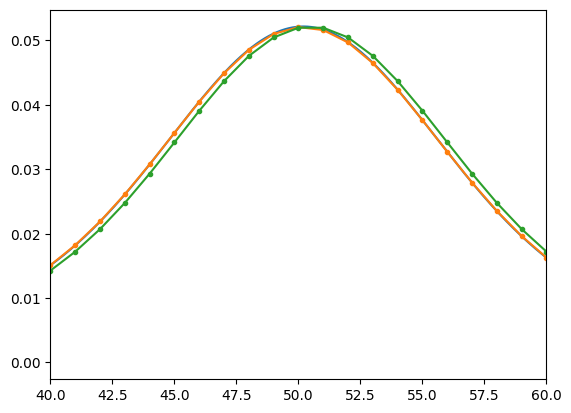

In [38]:
import numpy as np
import matplotlib.pyplot as plt

from ramlab.simulate import simulate_convolution, simulate_raw
from scipy.special import voigt_profile

x = np.arange(0, 100, 1)
x_fine = np.linspace(np.min(x), np.max(x), np.size(x)*100)

x_stick = np.array([50.2])
I_stick = np.array([1])

sigma = 4
gamma = 4

I_raw = simulate_raw(x, x_stick, I_stick, sigma=sigma, gamma=gamma, N_bin=10)
I_conv = simulate_convolution(x, x_stick, I_stick, sigma=sigma, gamma=gamma)
I_fine = voigt_profile(x_fine - x_stick, sigma, gamma)

A_fine = np.trapz(I_fine, x_fine)  
A_raw = np.trapz(I_raw, x)
A_conv = np.trapz(I_conv, x)

std_conv_vs_raw = np.std(I_conv - I_raw)

print("\t\t\t Fine \t\t Raw \t\t Conv")
print(f"Integral:\t\t {A_fine:.5f} \t {A_raw:.5f} \t {A_conv:.5f}")
print(f"Std:\t\t\t \t\t\t\t {np.std(I_conv):.5f}")
print(f"Max diff:\t\t \t\t\t\t {np.max(np.abs(I_conv - I_raw)):.5f}")

plt.figure()
plt.plot(x_fine, voigt_profile(x_fine - x_stick, sigma, gamma), label="Continuous function")
plt.plot(x, simulate_raw(x, x_stick, I_stick, sigma=sigma, gamma=gamma, N_bin=50), '.-')
plt.plot(x, simulate_convolution(x, x_stick, I_stick, sigma=sigma, gamma=gamma), '.-')
plt.xlim(40, 60)
